# Phase 1: Exploratory Data Analysis (EDA) & Data Cleaning

This notebook covers the following aspects of Milestone 1:
- Conducts a thorough statistical and visual exploration of all datasets (load, frequency, weather, holidays) to uncover insights.
- Effectively cleans the load data and handles outliers/gaps, justifying the methods based on your EDA findings.

Let's start by importing necessary libraries and loading the `Utility_consumption.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the historical load data
df_load = pd.read_csv('../Utility_consumption.csv')

# Display basic information and the first few rows
display(df_load.info())
display(df_load.head())


<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Datetime                   52416 non-null  str    
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   WindSpeed                  52416 non-null  float64
 4   F1_132KV_PowerConsumption  52416 non-null  float64
 5   F2_132KV_PowerConsumption  52416 non-null  float64
 6   F3_132KV_PowerConsumption  52416 non-null  float64
dtypes: float64(6), str(1)
memory usage: 2.8 MB


None

,Datetime,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
0,01-01-2017 00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
1,01-01-2017 00:10,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2,01-01-2017 00:20,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
3,01-01-2017 00:30,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
4,01-01-2017 00:40,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964


## 1.1 Understanding the Data and Feature Types

The dataset contains timestamps, weather variables (Temperature, Humidity, WindSpeed), and three feeders for 132KV power consumption. 
Notice that the Datetime format switches midway through the dataset (from `DD-MM-YYYY HH:MM` to `M/D/YYYY H:MM`). We will parse these robustly.


In [2]:
# Parse mixed datetime formats
df_load['Datetime'] = pd.to_datetime(df_load['Datetime'], format='mixed', dayfirst=True)

# Set Datetime as index
df_load.set_index('Datetime', inplace=True)
df_load.sort_index(inplace=True)

# Generate a summary of missing values
print("Missing values per column:\n", df_load.isnull().sum())


Missing values per column:
 Temperature                  0
Humidity                     0
WindSpeed                    0
F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
dtype: int64


## 1.2 Resampling to 30-Minute Blocks

The core objective requires forecasting for 30-minute blocks. The raw data is at 10-minute intervals. We will resample this down to 30 minutes. We can use the mean for temperature, humidity, windspeed, and power consumption.


In [3]:
# Resample to 30-minute intervals using the mean
df_30m = df_load.resample('30min').mean()

print(f"Data shape after resampling: {df_30m.shape}")
display(df_30m.head())


Data shape after resampling: (17472, 6)


,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
Datetime,,,,,,
2017-01-01 00:00:00,6.428667,74.266667,0.082000,30999.493670,18170.212767,20013.493977
2017-01-01 00:30:00,5.965000,75.866667,0.081667,27396.455697,17883.282673,18490.602410
2017-01-01 01:00:00,5.605000,78.000000,0.082000,25407.594937,16627.355623,17476.626507
2017-01-01 01:30:00,5.492667,77.166667,0.082000,23906.835443,15529.483283,16609.156627
2017-01-01 02:00:00,5.000667,78.766667,0.082667,22474.936707,14767.173253,15870.843373


## 1.3 Addressing Gaps, Errors, and Outliers in Load Data

Let's plot the total power consumption to visually inspect the data for gaps and outliers.


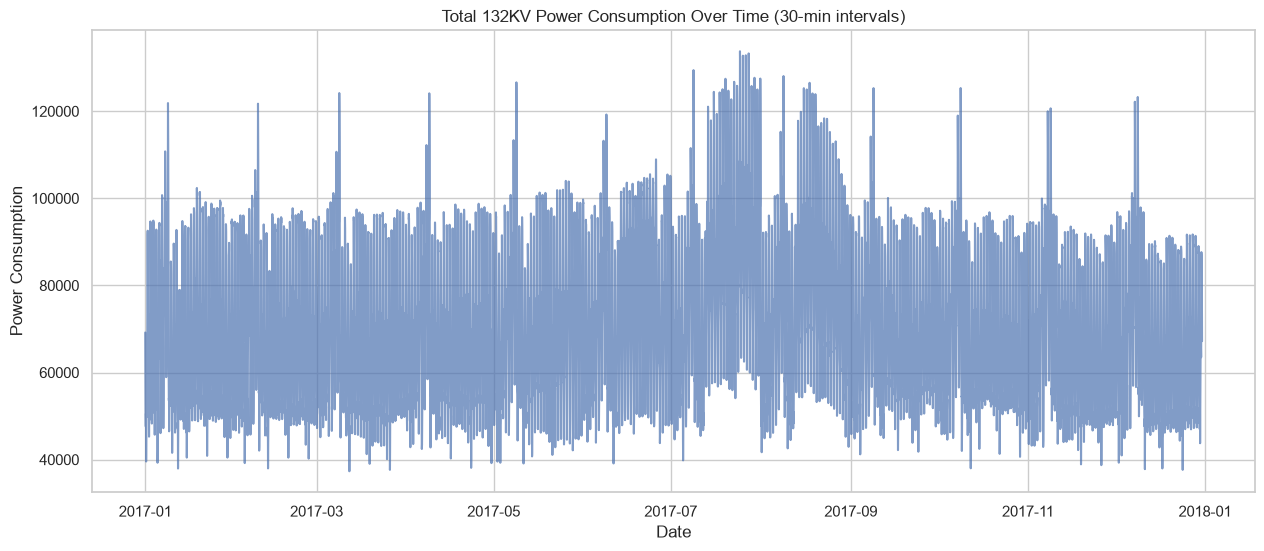

In [4]:
# Calculate total power consumption across all 3 feeders
df_30m['Total_PowerConsumption'] = df_30m['F1_132KV_PowerConsumption'] + df_30m['F2_132KV_PowerConsumption'] + df_30m['F3_132KV_PowerConsumption']

# Plot the total power consumption
plt.figure(figsize=(15, 6))
plt.plot(df_30m.index, df_30m['Total_PowerConsumption'], alpha=0.7)
plt.title('Total 132KV Power Consumption Over Time (30-min intervals)')
plt.ylabel('Power Consumption')
plt.xlabel('Date')
plt.show()


### Outlier Detection and Treatment
We will identify outliers using the Interquartile Range (IQR) method on the total power consumption and then interpolate missing or extreme values.


Number of outliers detected: 50


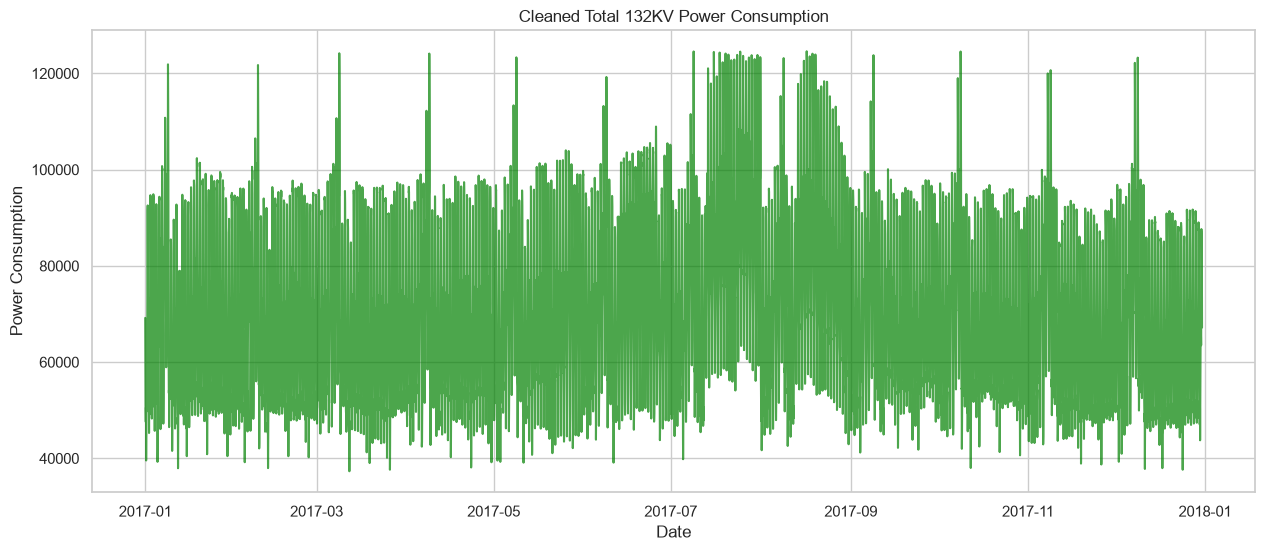

In [5]:
# Detect Outliers using IQR
Q1 = df_30m['Total_PowerConsumption'].quantile(0.25)
Q3 = df_30m['Total_PowerConsumption'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mark outliers as NaN so we can interpolate them along with actual missing gaps
outliers_mask = (df_30m['Total_PowerConsumption'] < lower_bound) | (df_30m['Total_PowerConsumption'] > upper_bound)
print(f"Number of outliers detected: {outliers_mask.sum()}")

df_clean = df_30m.copy()
df_clean.loc[outliers_mask, :] = np.nan

# Interpolate missing values (using time-based interpolation)
df_clean = df_clean.interpolate(method='time')

# Plot the cleaned data
plt.figure(figsize=(15, 6))
plt.plot(df_clean.index, df_clean['Total_PowerConsumption'], alpha=0.7, color='green')
plt.title('Cleaned Total 132KV Power Consumption')
plt.ylabel('Power Consumption')
plt.xlabel('Date')
plt.show()


## 1.4 Saving the Cleaned Data
We will save this cleaned 30-minute block dataset so it can be merged with weather and holiday data in the next phase.


In [6]:
# Save the cleaned dataframe
df_clean.to_csv('../Utility_consumption_cleaned.csv')
print("Cleaned data saved to 'Utility_consumption_cleaned.csv'")


Cleaned data saved to 'Utility_consumption_cleaned.csv'
